In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Shared "paper" look, kept in sync with the other benchmarking notebooks.
sns.set_theme(style="whitegrid", context="paper")

# Sized for a VLDB/SIGMOD/ICDE two-column camera-ready: figures go in at ~1:1, so the sizes here are
# the sizes on the page (body text is 9-10pt).
# Axis text sits above the ~1:1 sizes above: these figures are placed as narrow subfigures and
# scaled down further, so the labels have to start bigger to survive it.
PAPER_RC = {
    "axes.labelsize": 11,   # x- and y-axis labels
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "lines.markersize": 3,
    "pdf.fonttype": 42,  # TrueType, not Type-3: ACM/IEEE preflight rejects Type-3
    "ps.fonttype": 42,
}

# Column widths in inches: single column and full width of a two-column layout.
COL_W, FULL_W = 3.3, 7.0

# Two series: the analytical workload we care about (blue/solid) and the statistic queries added
# alongside it (orange/dashed) — separable at a glance and in grayscale.
SERIES_ORDER = ["analytical", "statistic"]
SERIES_LABEL = {
    "analytical": "Analytical (Q2 aggregations)",
    "statistic": "Statistic (histograms)",
}
_palette = sns.color_palette("colorblind")
SERIES_COLOR = {"analytical": _palette[0], "statistic": _palette[1]}
SERIES_STYLE = {"analytical": ("-", "o"), "statistic": ("--", "s")}

# Reference lines (baseline, fully-sustained diagonal) are deliberately neutral grey so they read as
# annotation rather than as a third series.
REF_COLOR = "0.45"

FIGURES = {}


def fmt_si(v):
    """Point/bar label: 15.9M / 1.6K / 4.7 — K/M/B suffixes with one decimal, never e-notation."""
    for div, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "K")):
        if abs(v) >= div:
            return f"{v / div:.1f}{suffix}"
    return f"{v:.1f}" if abs(v) >= 1 else f"{v:.2g}"


def style_axis(ax, grid_axis="y"):
    """The per-axis finishing every figure in these notebooks shares."""
    ax.grid(True, axis=grid_axis, linestyle=":", linewidth=0.4, alpha=0.6)
    ax.tick_params(length=2, width=0.6)
    sns.despine(ax=ax)


In [2]:
### Point BENCHMARK_RUN at a results directory (containing results_statistic_overhead.csv), or
### leave None to auto-pick the most recent benchmark_run_* under the notebook, the repo root or /tmp.
BENCHMARK_RUN = None

RESULTS_CSV = "results_statistic_overhead.csv"


def _has_results(d):
    return os.path.exists(os.path.join(d, RESULTS_CSV))


def _autopick_run():
    here = os.getcwd()
    if _has_results(here):
        return here
    repo_root = os.path.abspath(os.path.join(here, "..", "..", "..", ".."))
    candidates = []
    for base in (here, repo_root, "/tmp", os.path.expanduser("~")):
        # benchmark_run_* is the wrapper's default; bench-* is what we use on the remote, where
        # output must live outside the synced tree or rsync deletes it mid-run.
        candidates += glob.glob(os.path.join(base, "benchmark_run_*"))
        candidates += glob.glob(os.path.join(base, "bench-*"))
    candidates = [c for c in candidates if _has_results(c)]
    if not candidates:
        raise FileNotFoundError(f"No {RESULTS_CSV} found; set BENCHMARK_RUN explicitly.")
    return max(candidates, key=os.path.getmtime)


if BENCHMARK_RUN is None:
    BENCHMARK_RUN = _autopick_run()
print("Using results from:", os.path.abspath(BENCHMARK_RUN))


Using results from: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots


In [3]:
df = pd.read_csv(os.path.join(BENCHMARK_RUN, RESULTS_CSV))
_total = len(df)
# Drop only genuinely broken runs. A run that merely lost one query from the throughput listener is
# still usable: the headline metric is median-per-query, which is unaffected by a missing sample —
# that is precisely why it was chosen. Discarding those rows would throw away good data and thin out
# exactly the N values where the dropout happened.
_fatal = df["issue"].str.contains("exception|buffer exhaustion|no analytical throughput",
                                  case=False, na=False)
df = df[~_fatal].copy()

for col in ["analytical_throughput_tps", "analytical_throughput_median_tps",
            "statistic_throughput_tps", "offered_tps"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in ["num_statistic_queries", "run_idx", "num_analytical_queries", "num_worker_threads",
            "num_analytical_measured", "num_statistic_measured", "tuples_per_sec_per_query"]:
    df[col] = df[col].astype(int)
df = df.dropna(subset=["analytical_throughput_tps"])
df = df[df["analytical_throughput_tps"] > 0]

# Headline metric: median per-query throughput scaled to the workload, NOT the raw sum.
# The throughput listener needs two windows before it emits anything, so a query that deploys late
# can have all its windows land inside the warm-up and vanish from the sum entirely — dropping the
# total by ~1/N. At the calibrated operating point that is ~2 Mtup/s, an order of magnitude larger
# than the overhead being measured, and it would masquerade as overhead if it happened more often at
# high N. The median is unaffected by one missing query; num_analytical_measured below still flags it.
df["analytical_mtps"] = (df["analytical_throughput_median_tps"] * df["num_analytical_queries"]) / 1e6
df["analytical_sum_mtps"] = df["analytical_throughput_tps"] / 1e6
df["statistic_mtps"] = df["statistic_throughput_tps"] / 1e6
# What the engine was asked to ingest. Companions splice onto an existing source and pull nothing
# extra, so this is constant across the whole sweep — the denominator for "did the queries keep up?".
df["analytical_offered_tps"] = df["tuples_per_sec_per_query"] * df["num_analytical_queries"]
# tuples_per_sec_per_query == 0 means the generator was unpaced: there is no offered load to sustain
# a fraction OF, so leave it undefined rather than dividing by zero. Such a row still carries a
# valid measured throughput — it is the engine's ceiling.
df["analytical_offered_tps"] = df["analytical_offered_tps"].replace(0, np.nan)
df["analytical_offered_mtps"] = df["analytical_offered_tps"] / 1e6
# Median-based too, for the same reason as analytical_mtps: with the raw sum, one query missing
# from the listener would read as "only 90% sustained" and falsely suggest the operating point had
# fallen off the calibration knee.
df["sustained_frac"] = (df["analytical_throughput_median_tps"] * df["num_analytical_queries"]
                        / df["analytical_offered_tps"])

_dropped = df[df["num_analytical_measured"] != df["num_analytical_queries"]]
print(f"{len(df)}/{_total} rows usable"
      + (f"  ({len(_dropped)} with a query missing from the sum — headline metric is median-based, "
         f"so unaffected)" if len(_dropped) else ""))
print("offered rates (tup/s/query):", sorted(df["tuples_per_sec_per_query"].unique()))
print("statistic query counts:     ", sorted(df["num_statistic_queries"].unique()))

# A run where not every analytical query reported throughput is not comparable to one where they all
# did — the headline metric is a SUM over them, so a missing query silently lowers it. This is also
# exactly how buffer starvation shows up, so it is worth shouting about rather than averaging away.
_incomplete = df[df["num_analytical_measured"] != df["num_analytical_queries"]]
if len(_incomplete):
    print(f"\nWARNING: {len(_incomplete)} run(s) measured fewer analytical queries than submitted "
          f"— suspect buffer starvation, not overhead:")
    print(_incomplete[["tuples_per_sec_per_query", "num_statistic_queries", "run_idx",
                       "num_analytical_measured"]].to_string(index=False))
df.head()


55/55 rows usable  (7 with a query missing from the sum — headline metric is median-based, so unaffected)
offered rates (tup/s/query): [np.int64(2000000)]
statistic query counts:      [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

 tuples_per_sec_per_query  num_statistic_queries  run_idx  num_analytical_measured
                  2000000                      0        1                        9
                  2000000                      0        2                        9
                  2000000                      2        2                        9
                  2000000                      3        3                        9
                  2000000                      4        1                        9
                  2000000                      4        3                        9
                  2000000                      9        1                        9


,num_statistic_queries,run_idx,num_analytical_queries,num_worker_threads,window_size_sec,window_advance_sec,job_domain,events_per_sec,tuples_per_sec_per_query,offered_tps,...,num_analytical_measured,statistic_throughput_tps,num_statistic_measured,issue,analytical_mtps,analytical_sum_mtps,statistic_mtps,analytical_offered_tps,analytical_offered_mtps,sustained_frac
0,0,0,10,16,60,1,10000,100000,2000000,20000000,...,10,0,0,ok,19.999834,20.000046,0.0,20000000,20.0,0.999992
1,0,1,10,16,60,1,10000,100000,2000000,20000000,...,9,0,0,only 9/10 analytical queries measured,19.998750,17.975032,0.0,20000000,20.0,0.999938
2,0,2,10,16,60,1,10000,100000,2000000,20000000,...,9,0,0,only 9/10 analytical queries measured,20.000066,17.997288,0.0,20000000,20.0,1.000003
3,0,3,10,16,60,1,10000,100000,2000000,20000000,...,10,0,0,ok,20.000000,19.990525,0.0,20000000,20.0,1.000000
4,0,4,10,16,60,1,10000,100000,2000000,20000000,...,10,0,0,ok,20.000164,19.988158,0.0,20000000,20.0,1.000008


In [4]:
_base = df[df["num_statistic_queries"] == 0]
if _base["tuples_per_sec_per_query"].nunique() < 2:
    print("skipped (single offered rate — nothing to calibrate)")
else:
    calib = (_base.groupby("tuples_per_sec_per_query")
                  .agg(measured=("analytical_mtps", "mean"),
                       offered=("analytical_offered_mtps", "mean"))
                  .reset_index()
                  .sort_values("tuples_per_sec_per_query"))
    calib["sustained_pct"] = calib["measured"] / calib["offered"] * 100

    with sns.plotting_context("paper", rc=PAPER_RC):
        fig, ax = plt.subplots(figsize=(COL_W, 1.9))
        ax.plot(calib["offered"], calib["offered"], linestyle=":", linewidth=0.8, color=REF_COLOR,
                label="Fully sustained")
        ls, marker = SERIES_STYLE["analytical"]
        ax.plot(calib["offered"], calib["measured"], linestyle=ls, marker=marker,
                color=SERIES_COLOR["analytical"], label="Measured")
        # Log-log: past the knee the offered load runs away from the measured ceiling, and on linear
        # axes every point below the knee collapses against the origin.
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Offered analytical load [Mtup/s]")
        ax.set_ylabel("Sustained throughput\n[Mtup/s]")
        style_axis(ax, grid_axis="both")
        ax.legend(frameon=False, loc="upper left")
        FIGURES["StatisticOverhead_calibration"] = fig
        plt.show()

    print(calib.to_string(index=False))
    _knee = calib[calib["sustained_pct"] >= 95]["tuples_per_sec_per_query"]
    if len(_knee):
        print(f"\nhighest rate sustained >=95%: {int(_knee.max())} tup/s/query")
    print(f"measured ceiling: {calib['measured'].max():.3f} Mtup/s")


skipped (single offered rate — nothing to calibrate)


In [5]:
OPERATING_RATE = None  # None -> the rate carrying the most statistic-query counts

if OPERATING_RATE is None:
    OPERATING_RATE = int(df.groupby("tuples_per_sec_per_query")["num_statistic_queries"]
                           .nunique().idxmax())
_offered_m = OPERATING_RATE * df["num_analytical_queries"].iloc[0] / 1e6
print(f"operating point: {OPERATING_RATE} tup/s/query ({_offered_m:.2f} Mtup/s offered to the joins)")

_d = df[df["tuples_per_sec_per_query"] == OPERATING_RATE]
agg = (_d.groupby("num_statistic_queries")
         .agg(mean_mtps=("analytical_mtps", "mean"),
              std_mtps=("analytical_mtps", "std"),
              mean_stat_mtps=("statistic_mtps", "mean"),
              std_stat_mtps=("statistic_mtps", "std"),
              mean_sustained=("sustained_frac", "mean"),
              runs=("analytical_mtps", "size"))
         .reset_index()
         .sort_values("num_statistic_queries"))
agg[["std_mtps", "std_stat_mtps"]] = agg[["std_mtps", "std_stat_mtps"]].fillna(0.0)

_b = agg.loc[agg["num_statistic_queries"] == 0, "mean_mtps"]
BASELINE = float(_b.iloc[0]) if len(_b) else float("nan")
agg["pct_of_baseline"] = agg["mean_mtps"] / BASELINE * 100
agg["pct_std"] = agg["std_mtps"] / BASELINE * 100
print(f"baseline (N=0): {BASELINE:.3f} Mtup/s, sustaining "
      f"{agg.loc[agg['num_statistic_queries'] == 0, 'mean_sustained'].iloc[0]:.1%} of offered load")
agg


operating point: 2000000 tup/s/query (20.00 Mtup/s offered to the joins)
baseline (N=0): 20.000 Mtup/s, sustaining 100.0% of offered load


,num_statistic_queries,mean_mtps,std_mtps,mean_stat_mtps,std_stat_mtps,mean_sustained,runs,pct_of_baseline,pct_std
0,0,19.999763,0.000579,0.0,0.0,0.999988,5,100.000000,0.002895
1,1,20.000166,0.000526,0.0,0.0,1.000008,5,100.002014,0.002629
2,2,20.005909,0.010355,0.0,0.0,1.000295,5,100.030729,0.051774
3,3,19.380729,0.015696,0.0,0.0,0.969036,5,96.904795,0.078483
4,4,18.454275,0.052239,0.0,0.0,0.922714,5,92.272469,0.261199
5,5,17.606114,0.060404,0.0,0.0,0.880306,5,88.031612,0.302025
6,6,16.861246,0.272261,0.0,0.0,0.843062,5,84.307227,1.361321
7,7,16.211672,0.014801,0.0,0.0,0.810584,5,81.059320,0.074007
8,8,15.605830,0.130904,0.0,0.0,0.780291,5,78.030072,0.654530
9,9,15.042916,0.044284,0.0,0.0,0.752146,5,75.215469,0.221424


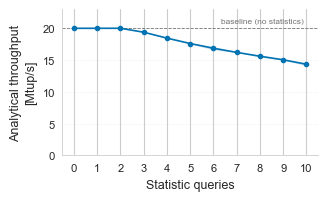

In [6]:
with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(COL_W, 1.9))
    x = agg["num_statistic_queries"].to_numpy()
    y = agg["mean_mtps"].to_numpy()
    e = agg["std_mtps"].to_numpy()
    color = SERIES_COLOR["analytical"]
    ls, marker = SERIES_STYLE["analytical"]

    ax.axhline(BASELINE, color=REF_COLOR, linewidth=0.6, linestyle="--", zorder=2)
    ### Rotated, and anchored at the LEFT end of the line: hanging it down from the right end runs
    ### the text straight through the last data points.
    ax.annotate("baseline (no statistics)", xy=(x.min(), BASELINE), xytext=(3, -3),
                textcoords="offset points", ha="left", va="top", rotation=90, fontsize=6,
                color=REF_COLOR)
    ax.fill_between(x, y - e, y + e, color=color, alpha=0.18, linewidth=0, zorder=3)
    ax.plot(x, y, linestyle=ls, marker=marker, color=color, zorder=4)

    ax.set_xlabel("Statistic queries")
    ax.set_ylabel("Analytical throughput\n[Mtup/s]")
    ax.set_xticks(x)
    ax.set_ylim(0, max(float((y + e).max()), BASELINE) * 1.15)
    style_axis(ax)
    FIGURES["StatisticOverhead_throughput"] = fig
    plt.show()


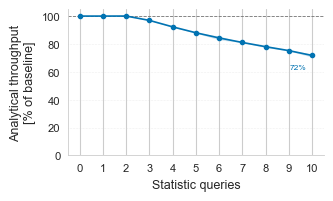

In [7]:
with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(COL_W, 1.9))
    x = agg["num_statistic_queries"].to_numpy()
    y = agg["pct_of_baseline"].to_numpy()
    e = agg["pct_std"].to_numpy()
    color = SERIES_COLOR["analytical"]
    ls, marker = SERIES_STYLE["analytical"]

    ax.axhline(100, color=REF_COLOR, linewidth=0.6, linestyle="--", zorder=2)
    ax.fill_between(x, y - e, y + e, color=color, alpha=0.18, linewidth=0, zorder=3)
    ax.plot(x, y, linestyle=ls, marker=marker, color=color, zorder=4)
    ax.annotate(f"{y[-1]:.0f}%", xy=(x[-1], y[-1]), xytext=(-4, -10), textcoords="offset points",
                ha="right", va="top", rotation=90, fontsize=6, color=color)

    ax.set_xlabel("Statistic queries")
    ax.set_ylabel("Analytical throughput\n[% of baseline]")
    ax.set_xticks(x)
    ax.set_ylim(0, max(105.0, float(np.nanmax(y + e)) + 2))
    style_axis(ax)
    FIGURES["StatisticOverhead_relative"] = fig
    plt.show()


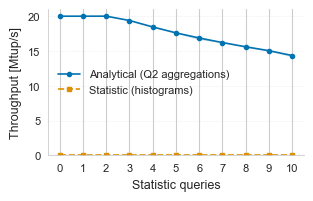

In [8]:
with sns.plotting_context("paper", rc=PAPER_RC):
    fig, ax = plt.subplots(figsize=(COL_W, 1.9))
    x = agg["num_statistic_queries"].to_numpy()
    for series, ycol, ecol in [("analytical", "mean_mtps", "std_mtps"),
                               ("statistic", "mean_stat_mtps", "std_stat_mtps")]:
        ls, marker = SERIES_STYLE[series]
        y, e = agg[ycol].to_numpy(), agg[ecol].to_numpy()
        ax.fill_between(x, y - e, y + e, color=SERIES_COLOR[series], alpha=0.15, linewidth=0)
        ax.plot(x, y, linestyle=ls, marker=marker, color=SERIES_COLOR[series],
                label=SERIES_LABEL[series])

    ax.set_xlabel("Statistic queries")
    ax.set_ylabel("Throughput [Mtup/s]")
    ax.set_xticks(x)
    ax.set_ylim(bottom=0)
    style_axis(ax)
    ax.legend(frameon=False, loc="center left")
    FIGURES["StatisticOverhead_breakdown"] = fig
    plt.show()


110761 samples at 2000000 tup/s/query


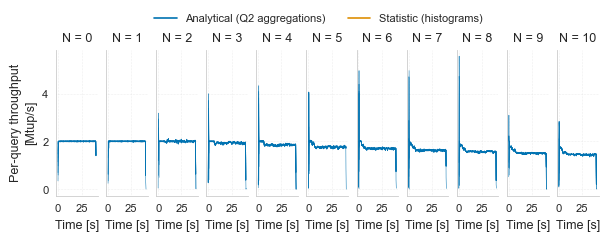

In [9]:
_files = sorted(glob.glob(os.path.join(BENCHMARK_RUN, "per_query_throughput_*.csv")))
if not _files:
    print("skipped (no per-query CSVs)")
else:
    _parts = []
    for path in _files:
        stem = os.path.basename(path)[len("per_query_throughput_"):-len(".csv")]
        rate_str, n_str, run_str = stem.split("_")
        part = pd.read_csv(path)
        part["tuples_per_sec_per_query"] = int(rate_str)
        part["num_statistic_queries"] = int(n_str)
        part["run_idx"] = int(run_str)
        _parts.append(part)
    pq = pd.concat(_parts, ignore_index=True)
    pq["throughput_mtps"] = pq["throughput_tps"] / 1e6
    pq = pq[pq["tuples_per_sec_per_query"] == OPERATING_RATE]

    _show = sorted(pq["num_statistic_queries"].unique())
    if not _show:
        print(f"skipped (no per-query samples at {OPERATING_RATE} tup/s/query)")
    else:
        print(f"{len(pq)} samples at {OPERATING_RATE} tup/s/query")
        with sns.plotting_context("paper", rc=PAPER_RC):
            width = min(FULL_W, max(COL_W, 1.5 * len(_show)))
            fig, axes = plt.subplots(1, len(_show), figsize=(width, 1.9),
                                     squeeze=False, sharey=True)
            for ax, n in zip(axes[0], _show):
                sub = pq[pq["num_statistic_queries"] == n]
                sub = sub[sub["run_idx"] == sub["run_idx"].min()]
                for series in SERIES_ORDER:
                    for _, g in sub[sub["role"] == series].groupby("query_id"):
                        g = g.sort_values("window_start_ms_normalized")
                        ax.plot(g["window_start_ms_normalized"] / 1000, g["throughput_mtps"],
                                color=SERIES_COLOR[series], linewidth=0.5, alpha=0.7)
                ax.set_title(f"N = {n}")
                ax.set_xlabel("Time [s]")
                style_axis(ax, grid_axis="both")
            axes[0][0].set_ylabel("Per-query throughput\n[Mtup/s]")
            handles = [plt.Line2D([], [], color=SERIES_COLOR[s], linewidth=1.2,
                                  label=SERIES_LABEL[s]) for s in SERIES_ORDER]
            fig.legend(handles=handles, frameon=False, ncol=2, loc="upper center",
                       bbox_to_anchor=(0.5, 1.12))
            FIGURES["StatisticOverhead_perquery"] = fig
            plt.show()


In [10]:
print(agg[["num_statistic_queries", "runs", "mean_mtps", "std_mtps",
           "mean_sustained", "pct_of_baseline"]].to_string(index=False))

_cv = agg["std_mtps"] / agg["mean_mtps"] * 100
print(f"\nrun-to-run CV: {_cv.min():.1f}% - {_cv.max():.1f}% "
      f"(a change smaller than this is not measurable with {int(agg['runs'].min())} runs)")
_drop = 100 - agg["pct_of_baseline"].iloc[-1]
print(f"drop at N={int(agg['num_statistic_queries'].iloc[-1])}: {_drop:.1f}% of baseline")

# Marginal cost of the Nth companion. A single fitted slope would hide the curvature, and the
# curvature is the finding: cost per synopsis FALLS as synopses are added, which is what shared
# scan/window state should do. Quote the range, not the average, unless the average is the point.
_marg = -agg.set_index("num_statistic_queries")["pct_of_baseline"].diff().dropna()
print("\nmarginal cost of the Nth companion [% of baseline]:")
print(_marg.round(2).to_string())
_free = agg[agg["pct_of_baseline"] >= 99.5]["num_statistic_queries"].max()
_paid = _marg[_marg.index > _free]
print(f"\nfree up to N={int(_free)}; beyond that {_paid.min():.1f}%-{_paid.max():.1f}% per companion "
      f"(mean {_paid.mean():.1f}%); peaks at N={int(_paid.idxmax())} then declines -> sublinear")

 num_statistic_queries  runs  mean_mtps  std_mtps  mean_sustained  pct_of_baseline
                     0     5  19.999763  0.000579        0.999988       100.000000
                     1     5  20.000166  0.000526        1.000008       100.002014
                     2     5  20.005909  0.010355        1.000295       100.030729
                     3     5  19.380729  0.015696        0.969036        96.904795
                     4     5  18.454275  0.052239        0.922714        92.272469
                     5     5  17.606114  0.060404        0.880306        88.031612
                     6     5  16.861246  0.272261        0.843062        84.307227
                     7     5  16.211672  0.014801        0.810584        81.059320
                     8     5  15.605830  0.130904        0.780291        78.030072
                     9     5  15.042916  0.044284        0.752146        75.215469
                    10     5  14.343613  0.245661        0.717181        71.718915

run

In [11]:
SAVE_DIR = os.path.join(BENCHMARK_RUN, "figures")
os.makedirs(SAVE_DIR, exist_ok=True)
if not FIGURES:
    print("no figures produced (no results found).")
for name, fig in FIGURES.items():
    for ext, kwargs in [("png", {"dpi": 300}), ("pdf", {})]:
        path = os.path.join(SAVE_DIR, f"{name}.{ext}")
        fig.savefig(path, bbox_inches="tight", pad_inches=0, **kwargs)
        print("saved:", os.path.abspath(path))


saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticOverhead_throughput.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticOverhead_throughput.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticOverhead_relative.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticOverhead_relative.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticOverhead_breakdown.png
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES/nebulastream-espat/scripts/benchmarking/statistic_overhead/plots/figures/StatisticOverhead_breakdown.pdf
saved: /Users/nils/Documents/TU_Berlin/Work_DIMA/NES